# 3D Molar Classification Model

## Binary Classification (Class 0 vs Class 1)
This notebook trains a ResNet-50 classification model on the 3D molar dataset and performs inference on synthesized image datasets.

**Model**: ResNet-50 (ImageNet pretrained)
**Image Size**: 128x128
**Dataset**: 3m-experimental-data-class0vsRest/original-dataset
**Inference**: 3m-Diff-128 and 3m-GAN-256 synthesized datasets
**Training**: Multi-GPU support (cuda:2 and cuda:3)

In [1]:
import os
import sys
import argparse
import shutil
import time
import random
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np

# Add models to path
sys.path.insert(0, '/home/sj/working_dir/3m-project-128/classification-models')
from utils import AverageMeter, accuracy

# Configuration
DATASET_PATH = '/home/sj/working_dir/3m-project-128/3m-experimental-data-class0vsRest/original-dataset'
CHECKPOINT_DIR = '/home/sj/working_dir/3m-project-128/classification-models/checkpoints/3dmolar'
INFERENCE_DIFF_PATH = '/home/sj/working_dir/3m-project-128/ThirdMolarProject/synthesized/3m-Diff-128'
INFERENCE_GAN_PATH = '/home/sj/working_dir/3m-project-128/ThirdMolarProject/synthesized/3m-GAN-256'
OUTPUT_DIFF_PATH = '/home/sj/working_dir/3m-project-128/3m-experimental-data-class0vsRest/diff-model-classified-dataset'
OUTPUT_GAN_PATH = '/home/sj/working_dir/3m-project-128/3m-experimental-data-class0vsRest/gan-model-classified-dataset'

IMAGE_SIZE = 128
NUM_CLASSES = 2
BATCH_SIZE = 64 
EPOCHS = 35
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

# GPU settings
PRIMARY_GPU = 3

# Create output directories if they don't exist
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIFF_PATH, exist_ok=True)
os.makedirs(OUTPUT_GAN_PATH, exist_ok=True)

print(f"Configuration:")
print(f"  Dataset: {DATASET_PATH}")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LR}")
print(f"  GPU: {PRIMARY_GPU}")

Configuration:
  Dataset: /home/sj/working_dir/3m-project-128/3m-experimental-data-class0vsRest/original-dataset
  Image Size: 128x128
  Batch Size: 64
  Epochs: 35
  Learning Rate: 0.1
  GPU: 3


In [2]:
class MolarDataset(Dataset):
    """Custom dataset loader for molar classification images"""
    
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Load images from class folders (0/ and 1/)
        for class_idx in range(NUM_CLASSES):
            class_dir = os.path.join(root_dir, str(class_idx))
            if os.path.exists(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        self.images.append(os.path.join(class_dir, img_name))
                        self.labels.append(class_idx)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        # Load and convert to RGB (in case of grayscale)
        img = Image.open(img_path).convert('RGB')
        
        # Resize to 128x128
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
        
        if self.transform:
            img = self.transform(img)
        
        return img, label


def get_data_loaders():
    """Create training and validation data loaders"""
    
    # Data augmentation for training
    train_transform = transforms.Compose([
        transforms.RandomCrop(IMAGE_SIZE, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])
    
    # No augmentation for validation
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])
    
    # Load full dataset for train
    train_dataset = MolarDataset(DATASET_PATH, transform=train_transform)
    
    # Split into train (80%) and validation (20%)
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = data.random_split(train_dataset, [train_size, val_size])
    
    # Apply validation transform to validation subset
    val_subset.dataset.transform = val_transform
    
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, 
                             shuffle=True, num_workers=2, pin_memory=False)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, 
                           shuffle=False, num_workers=2, pin_memory=False)
    
    print(f"Dataset loaded:")
    print(f"  Total: {len(train_dataset)}")
    print(f"  Train: {len(train_subset)}")
    print(f"  Validation: {len(val_subset)}")
    
    return train_loader, val_loader

print("Data loading utilities defined.")

Data loading utilities defined.


In [3]:
def create_model():
    """Create ResNet-50 model with pretrained weights"""
    print("Creating ResNet-50 model (standardized, proven architecture)...")
    from torchvision import models
    model = models.resnet50(pretrained=True)
    
    # Replace final FC layer for binary classification
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    
    return model


def train_epoch(model, train_loader, criterion, optimizer, epoch, device):
    """Train for one epoch"""
    model.train()
    
    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()
    top1 = AverageMeter()
    
    end = time.time()
    
    for batch_idx, (inputs, targets) in enumerate(tqdm(train_loader, desc=f'Train Epoch {epoch}')):
        data_time.update(time.time() - end)
        
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        batch_time.update(time.time() - end)
        losses.update(loss.item(), inputs.size(0))
        
        prec1 = accuracy(outputs, targets, topk=(1,))[0]
        top1.update(prec1.item(), inputs.size(0))
        
        end = time.time()
    
    return losses.avg, top1.avg


def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(tqdm(val_loader, desc='Validation')):
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            losses.update(loss.item(), inputs.size(0))
            prec1 = accuracy(outputs, targets, topk=(1,))[0]
            top1.update(prec1.item(), inputs.size(0))
    
    return losses.avg, top1.avg


print("Training utilities defined.")

Training utilities defined.


## Step 1: Load Data and Create DataLoaders

In [4]:
train_loader, val_loader = get_data_loaders()

Dataset loaded:
  Total: 5416
  Train: 4332
  Validation: 1084


## Step 2: Train the Model

In [5]:
# Clear GPU cache
torch.cuda.empty_cache()

# Set device
device = torch.device(f'cuda:{PRIMARY_GPU}' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Available GPUs: {torch.cuda.device_count()}")
print()

# Create model and move to device
model = create_model()
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 75], gamma=0.1)

# Training loop
best_acc = 0
best_epoch = 0
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("="*60)
print("Starting Training")
print("="*60 + "\n")

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end=" ")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, epoch+1, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")
    
    # Update learning rate
    scheduler.step()
    
    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = epoch + 1
        
        # Get the actual model (unwrap DataParallel if needed)
        model_to_save = model.module if isinstance(model, nn.DataParallel) else model
        
        checkpoint = {
            'epoch': epoch + 1,
            'state_dict': model_to_save.state_dict(),
            'acc': val_acc,
            'loss': val_loss,
            'optimizer': optimizer.state_dict(),
        }
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'model_best.pth')
        torch.save(checkpoint, checkpoint_path)
        print(f"  ✓ Best model saved (Acc: {val_acc:.2f}%)")
        checkpoint = {
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'acc': val_acc,
            'loss': val_loss,
            'optimizer': optimizer.state_dict(),
        }
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'model_best.pth')

Device: cuda:3
Available GPUs: 4

Creating ResNet-50 model (standardized, proven architecture)...


/home/sj/working_dir/new_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/sj/working_dir/new_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Total parameters: 23,512,130
  Trainable parameters: 23,512,130
Starting Training

Epoch [1/35] 

Validation: 100%|██████████| 17/17 [00:01<00:00,  8.58it/s]



| Train Loss: 1.6978 Acc: 61.84% | Val Loss: 0.6480 Acc: 65.13%
  ✓ Best model saved (Acc: 65.13%)
Epoch [2/35]   ✓ Best model saved (Acc: 65.13%)
Epoch [2/35] 

...

| Train Loss: 0.3877 Acc: 81.93% | Val Loss: 0.6026 Acc: 68.36%
Epoch [34/35] 

Validation: 100%|██████████| 17/17 [00:01<00:00,  8.94it/s]


| Train Loss: 0.3846 Acc: 82.09% | Val Loss: 0.6580 Acc: 71.68%
Epoch [35/35] 

Validation: 100%|██████████| 17/17 [00:01<00:00,  8.71it/s]

| Train Loss: 0.3848 Acc: 82.94% | Val Loss: 0.6698 Acc: 72.60%


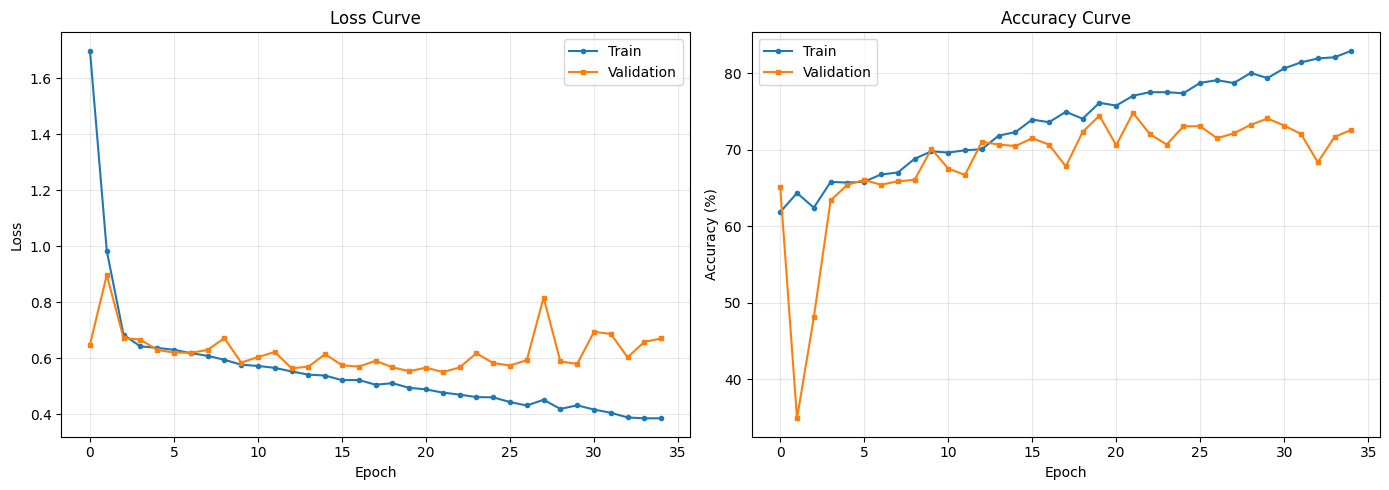

Training curves saved to /home/sj/working_dir/3m-project-128/classification-models/checkpoints/3dmolar/training_curves.png


In [6]:
import matplotlib.pyplot as plt

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train', marker='o', markersize=3)
axes[0].plot(val_losses, label='Validation', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train', marker='o', markersize=3)
axes[1].plot(val_accs, label='Validation', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to {CHECKPOINT_DIR}/training_curves.png")

## Step 3: Inference Function

In [7]:
def load_best_model(checkpoint_path, device):
    """Load the best trained model"""
    print(f"Loading model from: {checkpoint_path}")
    
    model = create_model()
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['state_dict'])
    model = model.to(device)
    model.eval()
    
    print(f"✓ Model loaded (Best Val Acc: {checkpoint['acc']:.2f}%)\n")
    return model


def preprocess_image(img_path, device):
    """Load and preprocess a single image for inference"""
    # Load image
    img = Image.open(img_path).convert('RGB')
    
    # Resize to 128x128
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
    
    # Apply normalization
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
    ])
    
    img_tensor = transform(img).unsqueeze(0).to(device)
    return img_tensor, img


def predict_image(model, img_tensor, device):
    """Predict class for a single image"""
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0, predicted_class].item()
    
    return predicted_class, confidence


def perform_inference(model, source_dir, output_dir, dataset_name, device):
    """
    Perform inference on all images in source directory
    and save predictions with class prefix
    """
    print(f"\n{'='*60}")
    print(f"Performing inference on: {dataset_name}")
    print(f"Source: {source_dir}")
    print(f"Output: {output_dir}")
    print(f"{'='*60}\n")
    
    if not os.path.exists(source_dir):
        print(f"✗ Source directory not found: {source_dir}")
        return
    
    # Get all image files
    image_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif'}
    image_files = [f for f in os.listdir(source_dir) 
                   if os.path.splitext(f)[1].lower() in image_extensions]
    
    print(f"Found {len(image_files)} images to process\n")
    
    if len(image_files) == 0:
        print("✗ No images found in source directory")
        return
    
    results = {0: [], 1: []}
    
    # Process each image
    for i, img_file in enumerate(tqdm(image_files, desc=f"Processing {dataset_name}")):
        try:
            img_path = os.path.join(source_dir, img_file)
            
            # Preprocess
            img_tensor, original_img = preprocess_image(img_path, device)
            
            # Predict
            predicted_class, confidence = predict_image(model, img_tensor, device)
            
            # Create output filename with class prefix and confidence percentage
            name, ext = os.path.splitext(img_file)
            confidence_pct = int(confidence * 100)
            output_filename = f"{predicted_class}_{name}_conf{confidence_pct}{ext}"
            output_path = os.path.join(output_dir, output_filename)
            
            # Save image
            original_img.save(output_path)
            results[predicted_class].append((img_file, confidence))
            
        except Exception as e:
            print(f"✗ Error processing {img_file}: {str(e)}")
    
    # Print statistics
    print(f"\n{'='*60}")
    print(f"Inference Results for {dataset_name}:")
    print(f"{'='*60}")
    print(f"Class 0 predictions: {len(results[0])}")
    print(f"Class 1 predictions: {len(results[1])}")
    print(f"Total processed: {len(results[0]) + len(results[1])}")
    
    if results[0]:
        avg_conf_0 = sum(c for _, c in results[0]) / len(results[0])
        print(f"Avg confidence (Class 0): {avg_conf_0:.4f}")
    
    if results[1]:
        avg_conf_1 = sum(c for _, c in results[1]) / len(results[1])
        print(f"Avg confidence (Class 1): {avg_conf_1:.4f}")
    
    print(f"{'='*60}\n")

print("Inference utilities defined.")

Inference utilities defined.


## Step 4: Run Inference on Synthesized Datasets

In [8]:
# Load best model (inference on primary GPU)
inference_device = torch.device(f'cuda:{PRIMARY_GPU}' if torch.cuda.is_available() else 'cpu')
best_model_path = os.path.join(CHECKPOINT_DIR, 'model_best.pth')
inference_model = load_best_model(best_model_path, inference_device)

# Run inference on Diff-128 dataset
perform_inference(
    model=inference_model,
    source_dir=INFERENCE_DIFF_PATH,
    output_dir=OUTPUT_DIFF_PATH,
    dataset_name="3m-Diff-128",
    device=inference_device
)

# Run inference on GAN-256 dataset
perform_inference(
    model=inference_model,
    source_dir=INFERENCE_GAN_PATH,
    output_dir=OUTPUT_GAN_PATH,
    dataset_name="3m-GAN-256",
    device=inference_device
)

print("\n✓ All inference completed!")

Loading model from: /home/sj/working_dir/3m-project-128/classification-models/checkpoints/3dmolar/model_best.pth
Creating ResNet-50 model (standardized, proven architecture)...


/tmp/ipykernel_1216362/174166503.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


  Total parameters: 23,512,130
  Trainable parameters: 23,512,130
✓ Model loaded (Best Val Acc: 74.82%)


Performing inference on: 3m-Diff-128
Source: /home/sj/working_dir/3m-project-128/ThirdMolarProject/synthesized/3m-Diff-128
Output: /home/sj/working_dir/3m-project-128/3m-experimental-data-class0vsRest/diff-model-classified-dataset

Found 3000 images to process



Processing 3m-Diff-128: 100%|██████████| 3000/3000 [03:29<00:00, 14.34it/s]




Inference Results for 3m-Diff-128:
Class 0 predictions: 2241
Class 1 predictions: 759
Total processed: 3000
Avg confidence (Class 0): 0.8123
Avg confidence (Class 1): 0.6559


Performing inference on: 3m-GAN-256
Source: /home/sj/working_dir/3m-project-128/ThirdMolarProject/synthesized/3m-GAN-256
Output: /home/sj/working_dir/3m-project-128/3m-experimental-data-class0vsRest/gan-model-classified-dataset

Found 4000 images to process



Processing 3m-GAN-256: 100%|██████████| 4000/4000 [05:05<00:00, 13.09it/s]


Inference Results for 3m-GAN-256:
Class 0 predictions: 2469
Class 1 predictions: 1531
Total processed: 4000
Avg confidence (Class 0): 0.7867
Avg confidence (Class 1): 0.6775


✓ All inference completed!
